<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Benchmark 4 - Legacy Peanuts Pipeline Profiler
---

This notebook profiles the legacy `peanuts` (NumPy + Numba) solar-to-detector pipeline stage by stage, mirroring `benchmark3_tpeanuts_profiler.ipynb`. Its goal is the same: locate where time and function-call cost actually go inside `peanuts`, not to compare against `tpeanuts`.

`peanuts` differs from `tpeanuts` in one profiling-relevant way: most of its numerical code is decorated with Numba `@njit`, which JIT-compiles to native machine code on first call. This has two consequences handled explicitly below: (1) the *first* call to any such function pays a compilation cost that must not be counted as steady-state performance, and (2) once compiled, `cProfile`/`line_profiler` cannot see *inside* a `@njit` function — it appears as a single opaque call. Section 7 works around the second point by re-running a profile in a fresh subprocess with Numba's JIT disabled, trading speed for visibility.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: profiling methodology and the Numba-specific caveats |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** - paths, legacy objects, and profiling helpers |
| [3](#3.-Numba-JIT-Warm-up-Cost) | **Numba JIT Warm-up Cost** |
| [4](#4.-Solar-Production-Stage) | **Solar Production Stage** |
| [5](#5.-Earth-Propagation-Stage) | **Earth Propagation Stage** |
| [6](#6.-Solar-to-Detector-Chain) | **Solar-to-Detector Chain** |
| [7](#7.-Looking-Inside-Numba) | **Looking Inside Numba** (JIT-disabled subprocess profiling) |
| [8](#8.-Bottleneck-Scaling-with-Grid-Size) | **Bottleneck Scaling with Grid Size** |
| [9](#9.-Summary) | **Summary**: ranked bottlenecks across every profiled scenario |

## 0. Theory Background

### 0.1 Same Methodology as `benchmark3`

Warm-up before measuring, repeat many calls under `cProfile`, sort by `tottime` (self time) to find the true bottleneck and by `cumtime` to see which call-tree branch it lives under. See `benchmark3_tpeanuts_profiler.ipynb` Section 0 for the full rationale; it is not repeated here.

### 0.2 The Numba Complication

`peanuts/earth.py`, `solar.py`, `pmns.py`, `potentials.py`, `matter_mixing.py`, `evolutor.py`, and `integration.py` are decorated with `@njit`. Two consequences:

- **Compilation cost on first call.** The very first call to a given `@njit` function (with a given argument-type signature) triggers LLVM compilation, which can take hundreds of milliseconds — orders of magnitude more than the steady-state call itself. Section 3 measures this directly. Every profiling section after it performs a warm-up first, exactly to avoid this contaminating the measurement.
- **Opaque to `cProfile` once compiled.** A compiled `@njit` function runs as native code with no Python frames underneath it, so `cProfile` (which instruments the Python interpreter's call/return events) sees it as a single leaf call — it cannot tell you which internal computation inside that function is expensive. Sections 4–6 below still profile normally (informative about Python-level looping and glue code, and about how much total time is spent inside each opaque `@njit` call), but Section 7 additionally reruns one stage in a subprocess with the `NUMBA_DISABLE_JIT=1` environment variable set *before* `peanuts` is imported, which forces every `@njit` function to run as plain Python. This exposes the full internal call tree to `cProfile`, at the cost of losing JIT speed — useful for understanding *what* is expensive, not *how fast* it normally runs.

### 0.3 Pipeline Stages Profiled

| Stage | Function |
|-------|----------|
| Solar production | `Psolar` (looped over energy; `peanuts` has no batched/vectorized entry point) |
| Earth propagation | `Pearth` (looped over energy and nadir angle) |
| Solar-to-detector chain | `solar_flux_mass` followed by `Pearth` |

---

**References**

- S. Almumin et al. / original `peanuts` authors — reference NumPy+Numba implementation bundled with this repository under `peanuts/`.
- Numba documentation — `@njit`, lazy compilation, `NUMBA_DISABLE_JIT`.

## 1. Libraries

In [1]:
from __future__ import annotations

import cProfile
import os
import pstats
import subprocess
import sys
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.util.context import RuntimeContext

from peanuts.solar import SolarModel, Psolar, solar_flux_mass
from peanuts.earth import Pearth, earthdensity
from peanuts.pmns import PMNS

import numba
print(f"Numba version: {numba.__version__}")

Warning!: Python module pyslha not found, disabling slha reading routines
Numba version: 0.63.1


## 2. Paths and Configuration

### 2.1 Paths

Same shared notebook configuration as the other benchmark notebooks. Legacy models receive explicit bundled data paths and require no package-data copying.

In [2]:
config = load_notebook_config()

PACKAGE_DIR = config.package_dir
OUTPUT_DIR = config.output_dir("benchmark")
LEGACY_DATA_DIR = config.legacy_data_dir

EARTH_DENSITY_LEGACY = str(LEGACY_DATA_DIR / "earth_density.csv")
SOLAR_MODEL_FILE = str(LEGACY_DATA_DIR / "nudistr_b16_agss09.dat")
SOLAR_FLUX_FILE = str(LEGACY_DATA_DIR / "fluxes_b16.dat")
SPECTRUM_FILES = {
    "8B":         str(LEGACY_DATA_DIR / "8B_shape_Ortiz_et_al.csv"),
    "hep":        str(LEGACY_DATA_DIR / "hep_shape.csv"),
    "pp":         str(LEGACY_DATA_DIR / "pp_shape.csv"),
    "17F":        str(LEGACY_DATA_DIR / "f17_shape.csv"),
    "7Beground":  str(LEGACY_DATA_DIR / "be7ground_shape.csv"),
    "7Beexcited": str(LEGACY_DATA_DIR / "be7excited_shape.csv"),
    "13N":        str(LEGACY_DATA_DIR / "n13_shape.csv"),
    "15O":        str(LEGACY_DATA_DIR / "o15_shape.csv"),
}

print(f"PACKAGE_DIR = {PACKAGE_DIR}")
print(f"Legacy data dir: {LEGACY_DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Legacy data dir: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\peanuts
Output directory: v:\output\benchmark


### 2.2 Configuration

Oscillation parameters are taken from the same NuFIT-preset used throughout the project (via `tpeanuts`, only to extract consistent numeric values — no `tpeanuts` computation happens in this notebook) so this profile reflects the same physics point as `benchmark3_tpeanuts_profiler.ipynb`.

In [3]:
_ctx = RuntimeContext.resolve("cpu", None)
_oscillation = PropagationConfig.oscillation_parameters_from_preset(context=_ctx, antinu=False)
_pmns = _oscillation.pmns
THETA12 = float(_pmns.params.theta12.detach().cpu())
THETA13 = float(_pmns.params.theta13.detach().cpu())
THETA23 = float(_pmns.params.theta23.detach().cpu())
DELTA_CP = float(_pmns.params.delta.detach().cpu())
DM21_EV2 = float(_oscillation.mass_spectrum.DeltamSq21.detach().cpu())
DM3L_EV2 = float(_oscillation.mass_spectrum.DeltamSq3l.detach().cpu())

legacy_pmns = PMNS(THETA12, THETA13, THETA23, DELTA_CP)
legacy_model = SolarModel(solar_model_file=SOLAR_MODEL_FILE, flux_file=SOLAR_FLUX_FILE, spectrum_files=SPECTRUM_FILES)
earth_density_l = earthdensity(density_file=EARTH_DENSITY_LEGACY, tabulated_density=False)

SOLAR_SOURCE = "8B"
EARTH_DEPTH_M = 0.0
SOLAR_DETECTOR_DEPTH_M = 1000.0
MASS_WEIGHTS_NP = np.array([0.20, 0.30, 0.50])

# Legacy peanuts is a scalar, per-point implementation (no batching), so its
# per-call cost is much higher than tpeanuts' for the same grid — these grids
# are deliberately smaller than benchmark3's to keep profiling runtime reasonable.
LARGE_NE_SOLAR = 512
LARGE_NE_EARTH = 32
LARGE_NETA_EARTH = 32

PROFILE_REPEATS = 25
PROFILE_WARMUPS = 5

print("Configuration loaded.")
print(f"  LARGE_NE_SOLAR={LARGE_NE_SOLAR}")
print(f"  LARGE_NE_EARTH={LARGE_NE_EARTH}, LARGE_NETA_EARTH={LARGE_NETA_EARTH}")
print(f"  PROFILE_REPEATS={PROFILE_REPEATS}, PROFILE_WARMUPS={PROFILE_WARMUPS}")

Configuration loaded.
  LARGE_NE_SOLAR=512
  LARGE_NE_EARTH=32, LARGE_NETA_EARTH=32
  PROFILE_REPEATS=25, PROFILE_WARMUPS=5


### 2.3 Profiling Helpers

Same `cProfile` wrappers as `benchmark3_tpeanuts_profiler.ipynb` (no `torch.profiler` counterpart here — `peanuts` has no PyTorch tensor operations to profile at that level), plus `profile_in_subprocess`, used only in Section 7 to profile with Numba's JIT disabled.

In [4]:
def profile_function(func, *, repeats=None, warmups=None):
    # Warm up, then profile `repeats` calls to `func` with cProfile.
    repeats = PROFILE_REPEATS if repeats is None else repeats
    warmups = PROFILE_WARMUPS if warmups is None else warmups
    for _ in range(warmups):
        func()
    profiler = cProfile.Profile()
    profiler.enable()
    for _ in range(repeats):
        func()
    profiler.disable()
    return pstats.Stats(profiler)


def stats_to_dataframe(stats, *, limit=20, sort_by="tottime"):
    # Flatten a pstats.Stats object into a tidy DataFrame.
    items = sorted(
        stats.stats.items(),
        key=lambda kv: kv[1][2 if sort_by == "tottime" else 3],
        reverse=True,
    )
    rows = []
    for (filename, lineno, funcname), (cc, nc, tt, ct, _callers) in items[:limit]:
        short_file = Path(filename).name if filename not in ("~", "") else filename
        rows.append({
            "function": funcname,
            "file": short_file,
            "line": lineno,
            "ncalls": nc,
            "tottime_s": tt,
            "percall_tot_ms": (tt / nc * 1.0e3) if nc else 0.0,
            "cumtime_s": ct,
            "percall_cum_ms": (ct / cc * 1.0e3) if cc else 0.0,
            "location": f"{funcname} ({short_file}:{lineno})",
        })
    df = pd.DataFrame(rows)
    df.attrs["total_tottime_s"] = stats.total_tt
    return df


def plot_top_functions(df, title, filename, *, metric="tottime_s", top=15):
    # Horizontal bar chart of the top functions by the chosen metric.
    d = df.sort_values(metric, ascending=True).tail(top)
    fig, ax = plt.subplots(figsize=(9.5, 0.38 * len(d) + 1.5))
    ax.barh(d["location"], d[metric], color="C0")
    ax.set_xlabel(metric)
    ax.set_title(title)
    fig.tight_layout()
    save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


def profile_in_subprocess(script_body, *, disable_jit=True):
    # Run `script_body` (a self-contained Python script whose only remaining
    # placeholder is the literal token __PROF_PATH__) in a fresh subprocess,
    # optionally with Numba's JIT disabled, and return the loaded pstats.Stats.
    with tempfile.TemporaryDirectory() as tmp:
        prof_path = Path(tmp) / "out.prof"
        script_path = Path(tmp) / "script.py"
        final_script = script_body.replace("__PROF_PATH__", str(prof_path).replace("\\", "/"))
        script_path.write_text(final_script, encoding="utf-8")
        env = dict(os.environ)
        if disable_jit:
            env["NUMBA_DISABLE_JIT"] = "1"
        result = subprocess.run(
            [sys.executable, str(script_path)],
            capture_output=True, text=True, env=env, cwd=str(PACKAGE_DIR),
        )
        if result.returncode != 0:
            raise RuntimeError(f"subprocess failed (disable_jit={disable_jit}):\n{result.stderr}")
        return pstats.Stats(str(prof_path))


SHOW_PLOTS = config.show_plots
print("Profiling helpers defined.")

Profiling helpers defined.


## 3. Numba JIT Warm-up Cost

Measures the first call to `Psolar` and `Pearth` against the mean of five subsequent calls, in a fresh kernel where neither has been called yet. This is the concrete justification for the warm-up step used by every profiling section below — skipping it would attribute JIT compilation time to "the algorithm", which is misleading.

**Expected results:** the first call should be one to three orders of magnitude slower than the steady-state mean.

,function,first_call_ms,mean_after_ms,slowdown_factor
0,Psolar,3363.0951,0.14418,23325.669421
1,Pearth,34275.6548,0.07256,472376.685090


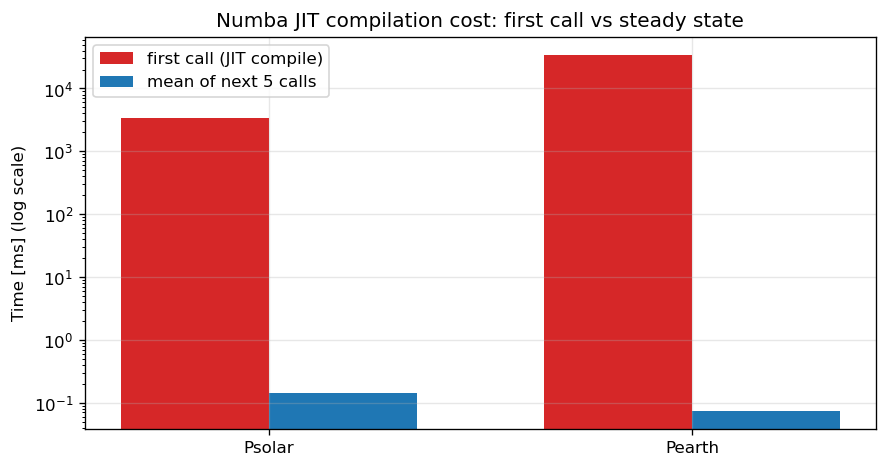

v:\output\benchmark\profiler_legacy_jit_warmup.png


In [5]:
def _time_once(func):
    t0 = time.perf_counter()
    func()
    return time.perf_counter() - t0

warmup_records = []
warmup_records.append(("Psolar", lambda: Psolar(
    legacy_pmns, DM21_EV2, DM3L_EV2, 5.0,
    legacy_model.radius(), legacy_model.density(), legacy_model.fraction(SOLAR_SOURCE),
)))
warmup_records.append(("Pearth", lambda: Pearth(
    MASS_WEIGHTS_NP, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2, 5.0, 1.0, EARTH_DEPTH_M,
    mode="analytical", massbasis=True,
)))

rows = []
for name, func in warmup_records:
    t_first = _time_once(func)
    t_after = [_time_once(func) for _ in range(5)]
    rows.append({
        "function": name,
        "first_call_ms": t_first * 1.0e3,
        "mean_after_ms": float(np.mean(t_after)) * 1.0e3,
        "slowdown_factor": t_first / max(float(np.mean(t_after)), 1.0e-9),
    })
warmup_df = pd.DataFrame(rows)
display(warmup_df)

fig, ax = plt.subplots(figsize=(7.5, 4.0))
x = np.arange(len(warmup_df))
w = 0.35
ax.bar(x - w / 2, warmup_df["first_call_ms"], width=w, label="first call (JIT compile)", color="C3")
ax.bar(x + w / 2, warmup_df["mean_after_ms"], width=w, label="mean of next 5 calls", color="C0")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(warmup_df["function"])
ax.set_ylabel("Time [ms] (log scale)")
ax.set_title("Numba JIT compilation cost: first call vs steady state")
ax.legend()
fig.tight_layout()
save_and_show("profiler_legacy_jit_warmup.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 4. Solar Production Stage

Profiles `Psolar` looped over an energy grid (there is no batched entry point in `peanuts` — each energy is a separate scalar call).

**Expected results:** unlike `tpeanuts`' `solar_probability_state` (one batched call), the top `cumtime` entry here should be the Python list comprehension itself, with `tottime` spread between the (opaque, JIT-compiled) `Psolar` call and the per-call `legacy_model.radius()`/`density()`/`fraction()` accessor calls.

,function,file,line,ncalls,tottime_s,percall_tot_ms,cumtime_s,percall_cum_ms
0,solar_flux_mass,solar.py,316,12800,1.355385,0.105889,1.363217,0.106501
1,Psolar,solar.py,342,12800,0.122855,0.009598,1.565376,0.122295
2,to_numpy,base.py,545,38400,0.067632,0.001761,0.153187,0.003989
3,wrapper,boxing.py,59,12800,0.034765,0.002716,0.057347,0.004480
4,<listcomp>,947520634.py,4,25,0.031974,1.278952,1.778045,71.121784
5,<built-in method numpy.array>,~,0,25600,0.019566,0.000764,0.019566,0.000764
6,_values,series.py,834,38400,0.016777,0.000437,0.027883,0.000726
7,dtype,managers.py,2012,38400,0.016455,0.000429,0.016455,0.000429
8,method,<string>,2,12800,0.016349,0.001277,0.022582,0.001764
9,dtype,series.py,710,38400,0.015804,0.000412,0.032260,0.000840


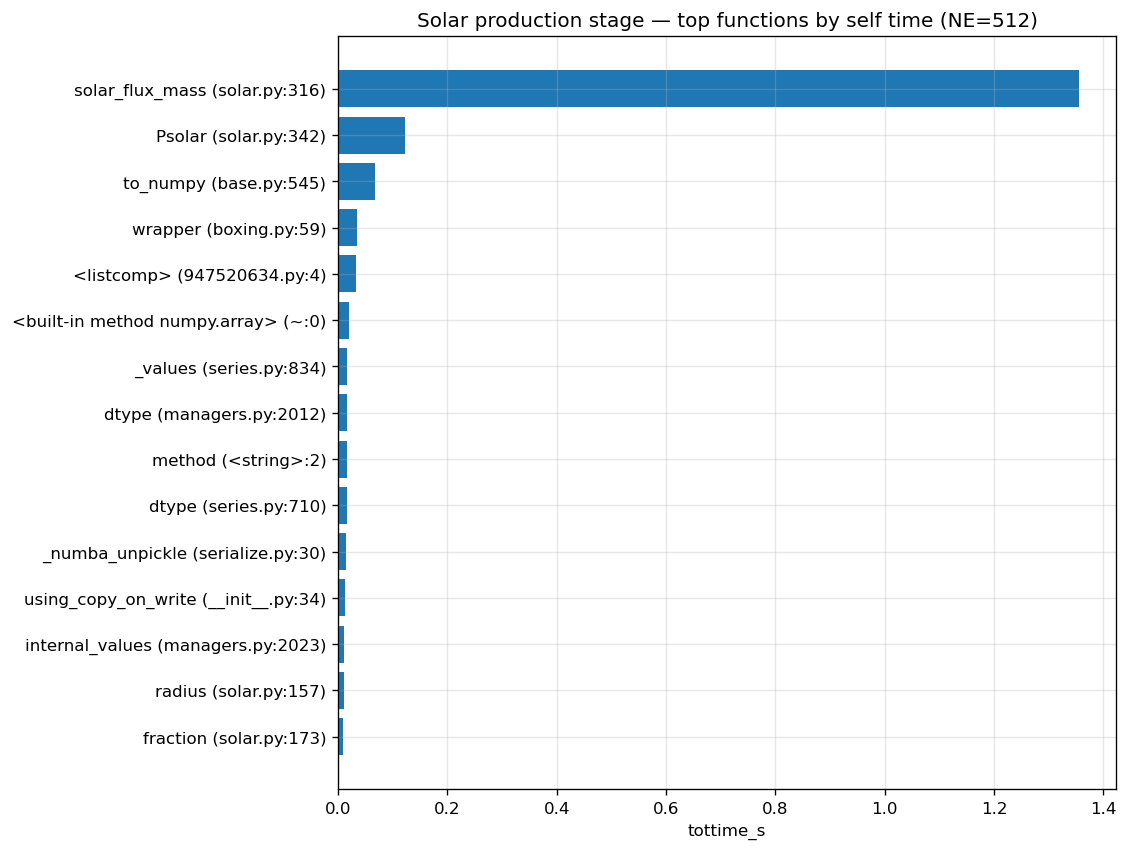

v:\output\benchmark\profiler_legacy_solar_top_functions.png


In [6]:
E_np_solar = np.linspace(0.5, 15.0, LARGE_NE_SOLAR)

def solar_stage():
    return np.stack([
        Psolar(
            legacy_pmns, DM21_EV2, DM3L_EV2, float(e),
            legacy_model.radius(), legacy_model.density(), legacy_model.fraction(SOLAR_SOURCE),
        )
        for e in E_np_solar
    ])

solar_stats = profile_function(solar_stage)
solar_df = stats_to_dataframe(solar_stats, limit=20, sort_by="tottime")
display(solar_df.drop(columns="location"))
plot_top_functions(solar_df, f"Solar production stage — top functions by self time (NE={LARGE_NE_SOLAR})",
                    "profiler_legacy_solar_top_functions.png")

## 5. Earth Propagation Stage

Profiles `Pearth` looped over an energy/nadir grid at the surface detector depth.

**Expected results:** most self time should be attributed to `Pearth` itself (and whatever helper it calls that is *not* JIT-compiled, such as Python-level PMNS construction), since the internal perturbative/shell computation is invisible to `cProfile` once compiled.

,function,file,line,ncalls,tottime_s,percall_tot_ms,cumtime_s,percall_cum_ms
0,Pearth_analytical,earth.py,404,25600,0.849986,0.033203,0.863996,0.033750
1,Pearth,earth.py,468,25600,0.111700,0.004363,0.978231,0.038212
2,<listcomp>,323036866.py,5,25,0.030722,1.228896,1.008953,40.358128
3,_numba_unpickle,serialize.py,30,25600,0.014011,0.000547,0.014011,0.000547
4,stack,shape_base.py,380,25,0.007826,0.313040,0.023717,0.948660
5,<listcomp>,shape_base.py,466,25,0.007268,0.290712,0.007268,0.290712
6,earth_stage,323036866.py,4,25,0.003674,0.146940,1.036629,41.465168
7,<listcomp>,shape_base.py,454,25,0.003538,0.141524,0.005657,0.226264
8,<setcomp>,shape_base.py,458,25,0.002906,0.116228,0.002906,0.116228
9,<built-in method builtins.len>,~,0,25625,0.002548,0.000099,0.002548,0.000099


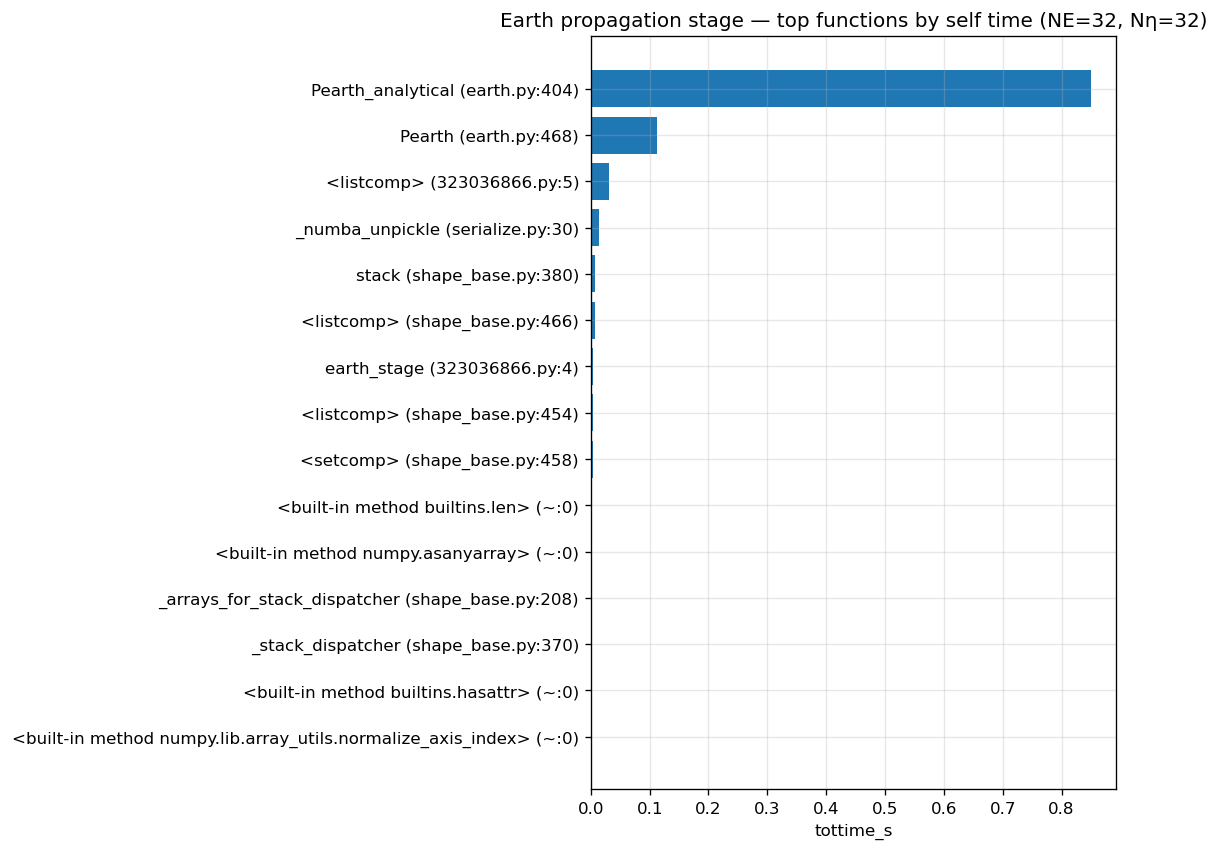

v:\output\benchmark\profiler_legacy_earth_top_functions.png


In [7]:
E_np_earth = np.linspace(0.5, 15.0, LARGE_NE_EARTH)
eta_np_earth = np.linspace(0.05, np.pi - 0.05, LARGE_NETA_EARTH)

def earth_stage():
    return np.stack([
        Pearth(
            MASS_WEIGHTS_NP, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2,
            float(e), float(a), EARTH_DEPTH_M, mode="analytical", massbasis=True,
        )
        for e in E_np_earth for a in eta_np_earth
    ])

earth_stats = profile_function(earth_stage)
earth_df = stats_to_dataframe(earth_stats, limit=20, sort_by="tottime")
display(earth_df.drop(columns="location"))
plot_top_functions(earth_df, f"Earth propagation stage — top functions by self time (NE={LARGE_NE_EARTH}, N\u03b7={LARGE_NETA_EARTH})",
                    "profiler_legacy_earth_top_functions.png")

## 6. Solar-to-Detector Chain

Profiles the full incoherent chain: `solar_flux_mass` followed by `Pearth` at the solar-detector depth, matching `benchmark1` Section 7 and `benchmark3` Section 5.

,function,file,line,ncalls,tottime_s,percall_tot_ms,cumtime_s,percall_cum_ms
0,Pearth_analytical,earth.py,404,25600,0.985930,0.038513,1.000956,0.039100
1,Pearth,earth.py,468,25600,0.119408,0.004664,1.123460,0.043885
2,solar_flux_mass,solar.py,316,800,0.089052,0.111315,0.089683,0.112104
3,<listcomp>,2889560773.py,8,800,0.033445,0.041806,1.156905,1.446132
4,_numba_unpickle,serialize.py,30,26400,0.015657,0.000593,0.015657,0.000593
5,stack,shape_base.py,380,825,0.014968,0.018142,0.031883,0.038646
6,solar_to_detector,2889560773.py,1,25,0.012377,0.495088,1.306909,52.276340
7,<listcomp>,shape_base.py,466,825,0.006514,0.007895,0.006514,0.007895
8,to_numpy,base.py,545,2400,0.005029,0.002095,0.011852,0.004938
9,<listcomp>,shape_base.py,454,825,0.003951,0.004789,0.006287,0.007620


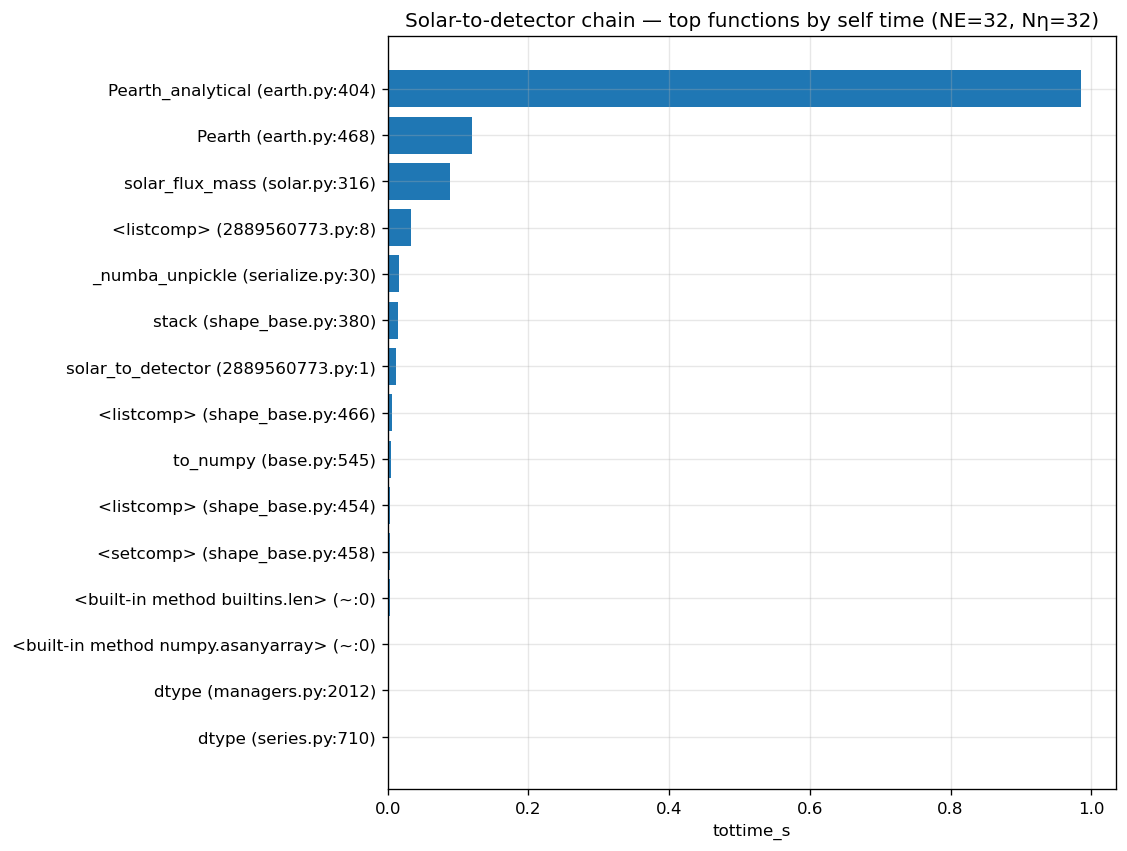

v:\output\benchmark\profiler_legacy_chain_top_functions.png
Chain total self time over 25 calls: 1.3069s (52.276 ms/call)


In [8]:
def solar_to_detector():
    rows = []
    for e in E_np_earth:
        mass = solar_flux_mass(
            legacy_pmns.theta12, legacy_pmns.theta13, DM21_EV2, DM3L_EV2, float(e),
            legacy_model.radius(), legacy_model.density(), legacy_model.fraction(SOLAR_SOURCE),
        )
        rows.append(np.stack([
            Pearth(
                mass, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2,
                float(e), float(a), SOLAR_DETECTOR_DEPTH_M, mode="analytical", massbasis=True,
            )
            for a in eta_np_earth
        ]))
    return np.stack(rows)

chain_stats = profile_function(solar_to_detector)
chain_df = stats_to_dataframe(chain_stats, limit=20, sort_by="tottime")
display(chain_df.drop(columns="location"))
plot_top_functions(chain_df, f"Solar-to-detector chain — top functions by self time (NE={LARGE_NE_EARTH}, N\u03b7={LARGE_NETA_EARTH})",
                    "profiler_legacy_chain_top_functions.png")

print(f"Chain total self time over {PROFILE_REPEATS} calls: {chain_stats.total_tt:.4f}s "
      f"({chain_stats.total_tt / PROFILE_REPEATS * 1e3:.3f} ms/call)")

## 7. Looking Inside Numba

Re-profiles the Earth-propagation stage (Section 5) in a fresh subprocess with Numba compiled normally (JIT enabled — the same opaque view as Section 5), and attempts the same with `NUMBA_DISABLE_JIT=1` set before `peanuts` is imported, which forces every plain `@njit` function to run as interpreted Python and become fully visible to `cProfile`.

The grid here is deliberately tiny (`NE=4`, `Nη=4`): pure-Python execution of code written for JIT compilation is dramatically slower (no native-code loop optimization), so this section is only useful for seeing *which internal functions exist and are called*, not for measuring realistic per-call cost.

**Expected results — and an actual limitation of this technique for this codebase:** the JIT-enabled subprocess reproduces Section 5's opaque `Pearth`-dominated profile. The JIT-disabled attempt is expected to *fail*: `peanuts.pmns.PMNS` is a Numba `@jitclass`, not a plain `@njit` function, and its methods build arrays with `np.array(..., dtype=nb.complex128)` — passing the Numba *type object* `nb.complex128` directly as a NumPy dtype. That only resolves correctly inside Numba's own compiled type system; once `NUMBA_DISABLE_JIT=1` forces plain-Python execution, plain NumPy receives `nb.complex128` as a literal object and raises `TypeError: Cannot interpret 'complex128' as a data type`. This is a real, useful finding in its own right: the `NUMBA_DISABLE_JIT` escape hatch is not guaranteed to work transparently for `@jitclass`-based code, so it is not a universal profiling technique — its applicability has to be checked per function/class, not assumed.

In [9]:
SUBPROCESS_SCRIPT = """
import cProfile
import numpy as np
from peanuts.earth import Pearth, earthdensity
from peanuts.pmns import PMNS

earth_density_l = earthdensity(density_file=r"{earth_density_legacy}", tabulated_density=False)
legacy_pmns = PMNS({theta12}, {theta13}, {theta23}, {delta_cp})
mass_weights = np.array([0.20, 0.30, 0.50])

E_np = np.linspace(0.5, 15.0, {ne})
eta_np = np.linspace(0.05, np.pi - 0.05, {neta})

def _call():
    return np.stack([
        Pearth(mass_weights, earth_density_l, legacy_pmns, {dm21}, {dm3l}, float(e), float(a), {depth_m},
               mode="analytical", massbasis=True)
        for e in E_np for a in eta_np
    ])

for _ in range({warmups}):
    _call()

_pr = cProfile.Profile()
_pr.enable()
for _ in range({repeats}):
    _call()
_pr.disable()
_pr.dump_stats(r"__PROF_PATH__")
""".format(
    earth_density_legacy=EARTH_DENSITY_LEGACY.replace("\\", "/"),
    theta12=THETA12, theta13=THETA13, theta23=THETA23, delta_cp=DELTA_CP,
    dm21=DM21_EV2, dm3l=DM3L_EV2, depth_m=EARTH_DEPTH_M,
    ne=4, neta=4, warmups=2, repeats=5,
)

jit_stats = profile_in_subprocess(SUBPROCESS_SCRIPT, disable_jit=False)
jit_df = stats_to_dataframe(jit_stats, limit=12, sort_by="tottime")
print("--- Numba JIT enabled (opaque) ---")
display(jit_df.drop(columns="location"))
print(f"Distinct functions visible: {len(jit_stats.stats)}")

no_jit_df = None
try:
    no_jit_stats = profile_in_subprocess(SUBPROCESS_SCRIPT, disable_jit=True)
    no_jit_df = stats_to_dataframe(no_jit_stats, limit=20, sort_by="tottime")
    print("\n--- Numba JIT disabled (transparent) ---")
    display(no_jit_df.drop(columns="location"))
    print(f"Distinct functions visible: {len(no_jit_stats.stats)}")
except RuntimeError as exc:
    print("\n--- Numba JIT disabled: FAILED (this is itself the finding - see markdown above) ---")
    tail = str(exc).strip().splitlines()[-1]
    print(f"Root cause (last line of the subprocess traceback): {tail}")

--- Numba JIT enabled (opaque) ---


,function,file,line,ncalls,tottime_s,percall_tot_ms,cumtime_s,percall_cum_ms
0,Pearth_analytical,earth.py,404,80,0.003331,0.041635,0.003385,0.042307
1,Pearth,earth.py,468,80,0.000458,0.005729,0.003853,0.048159
2,<listcomp>,script.py,15,5,0.000133,0.026560,0.003986,0.797100
3,stack,shape_base.py,380,5,0.000093,0.018680,0.000163,0.032520
4,_numba_unpickle,serialize.py,30,80,0.000054,0.000673,0.000054,0.000673
5,_call,script.py,14,5,0.000037,0.007440,0.004205,0.840940
6,<listcomp>,shape_base.py,466,5,0.000027,0.005320,0.000027,0.005320
7,<listcomp>,shape_base.py,454,5,0.000015,0.003080,0.000023,0.004600
8,<setcomp>,shape_base.py,458,5,0.000015,0.003000,0.000015,0.003000
9,<built-in method builtins.len>,~,0,85,0.000010,0.000122,0.000010,0.000122


Distinct functions visible: 17



--- Numba JIT disabled: FAILED (this is itself the finding - see markdown above) ---
Root cause (last line of the subprocess traceback): TypeError: Cannot interpret 'complex128' as a data type


## 8. Bottleneck Scaling with Grid Size

Repeats the Earth-propagation-stage profile (Section 5) at several grid sizes and tracks what fraction of total self time the top-5 functions each represent, exactly like `benchmark3` Section 8. Since `peanuts` loops in Python over every grid point, the expectation here is different from `tpeanuts`: with no batching, per-call overhead is paid once *per grid point* rather than once *per call*, so shares should stay comparatively stable across grid sizes rather than shrinking.

function,Pearth_analytical,Pearth,<listcomp>,_numba_unpickle,stack
n_energy,,,,,
4,0.811708,0.106333,0.032615,0.012812,0.012148
8,0.822178,0.103108,0.031135,0.012468,0.009241
16,0.824653,0.102306,0.031653,0.012798,0.007838
32,0.825109,0.103142,0.031424,0.012680,0.007306


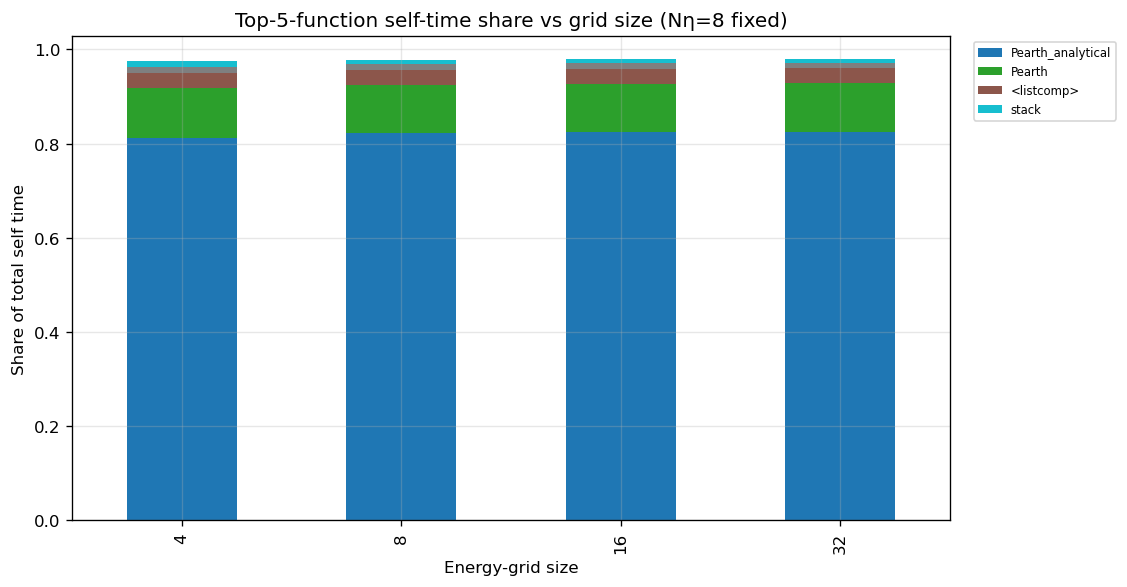

v:\output\benchmark\profiler_legacy_scaling_shares.png


In [10]:
SCALING_NE_SIZES = [4, 8, 16, 32]
SCALING_NETA = 8

scaling_records = []
top5_names_seen = []

for ne in SCALING_NE_SIZES:
    E_s = np.linspace(0.5, 15.0, ne)
    eta_s = np.linspace(0.05, np.pi - 0.05, SCALING_NETA)

    def call(E_s=E_s, eta_s=eta_s):
        return np.stack([
            Pearth(
                MASS_WEIGHTS_NP, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2,
                float(e), float(a), EARTH_DEPTH_M, mode="analytical", massbasis=True,
            )
            for e in E_s for a in eta_s
        ])

    stats = profile_function(call, repeats=15, warmups=3)
    df = stats_to_dataframe(stats, limit=5, sort_by="tottime")
    for name in df["function"]:
        if name not in top5_names_seen:
            top5_names_seen.append(name)
    for _, row in df.iterrows():
        scaling_records.append({
            "n_energy": ne,
            "function": row["function"],
            "share": row["tottime_s"] / stats.total_tt,
        })

scaling_df = pd.DataFrame(scaling_records)
pivot = scaling_df.pivot_table(index="n_energy", columns="function", values="share", fill_value=0.0)
pivot = pivot[[c for c in top5_names_seen if c in pivot.columns]]
display(pivot)

fig, ax = plt.subplots(figsize=(9.5, 5.0))
pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel("Energy-grid size")
ax.set_ylabel("Share of total self time")
ax.set_title(f"Top-5-function self-time share vs grid size (N\u03b7={SCALING_NETA} fixed)")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1.0), loc="upper left")
fig.tight_layout()
save_and_show("profiler_legacy_scaling_shares.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 9. Summary

Combines the per-function `tottime` share from every profiled scenario above into one ranked table.

,function,appears_in_n_scenarios,mean_share,max_share
7,<listcomp>,3,0.011698,0.029637
14,_numba_unpickle,3,0.011115,0.013515
27,stack,3,0.007053,0.011453
11,Pearth_analytical,2,0.787173,0.819949
25,solar_flux_mass,2,0.412251,0.756362
10,Pearth,2,0.099559,0.107752
28,to_numpy,2,0.020795,0.037741
16,_values,2,0.005133,0.009362
19,dtype,2,0.005043,0.009183
29,using_copy_on_write,2,0.003714,0.006709


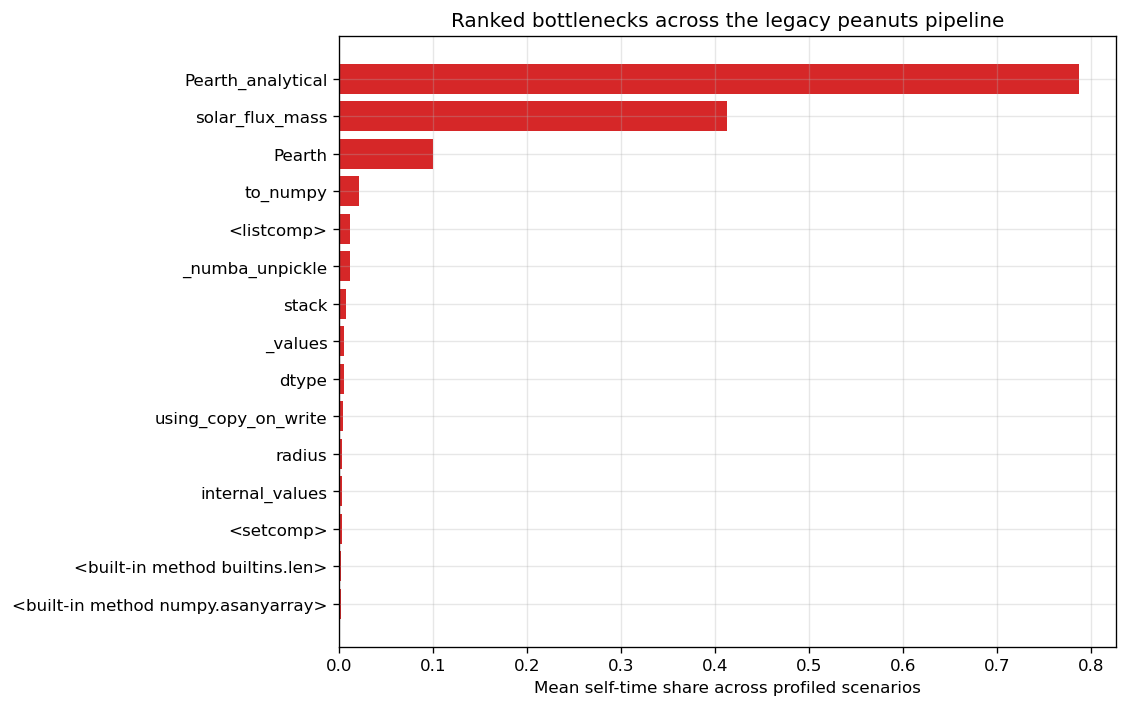

v:\output\benchmark\profiler_legacy_summary_ranked_bottlenecks.png
Saved: v:\output\benchmark\profiler_legacy_summary.csv


In [11]:
scenario_dfs = {
    "solar_production": solar_df,
    "earth_propagation": earth_df,
    "solar_to_detector_chain": chain_df,
}
if no_jit_df is not None:
    scenario_dfs["earth_propagation_jit_disabled"] = no_jit_df

combined_rows = []
for scenario, df in scenario_dfs.items():
    total = df.attrs.get("total_tottime_s") or df["tottime_s"].sum()
    for _, row in df.iterrows():
        combined_rows.append({
            "scenario": scenario,
            "function": row["function"],
            "location": row["location"],
            "share_of_scenario": row["tottime_s"] / total if total else 0.0,
        })
combined_df = pd.DataFrame(combined_rows)

summary = (
    combined_df.groupby("function", as_index=False)
    .agg(
        appears_in_n_scenarios=("scenario", "nunique"),
        mean_share=("share_of_scenario", "mean"),
        max_share=("share_of_scenario", "max"),
    )
    .sort_values(["appears_in_n_scenarios", "mean_share"], ascending=False)
)
display(summary.head(20))

fig, ax = plt.subplots(figsize=(9.5, 6.0))
top_summary = summary.head(15).sort_values("mean_share")
ax.barh(top_summary["function"], top_summary["mean_share"], color="C3")
ax.set_xlabel("Mean self-time share across profiled scenarios")
ax.set_title("Ranked bottlenecks across the legacy peanuts pipeline")
fig.tight_layout()
save_and_show("profiler_legacy_summary_ranked_bottlenecks.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

summary.to_csv(OUTPUT_DIR / "profiler_legacy_summary.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'profiler_legacy_summary.csv'}")

## 10. Conclusions

This notebook locates the bottleneck functions of the legacy `peanuts` solar-to-detector pipeline directly. Section 3 quantifies the Numba warm-up cost that every subsequent section's warm-up step exists to avoid measuring. Section 7 demonstrates concretely why `cProfile` alone under-reports what happens inside a JIT-compiled pipeline, and how to recover that visibility (at the cost of realistic timing) by disabling the JIT in a throwaway subprocess. Section 8 shows the scaling-with-grid-size picture for an unbatched, per-point implementation, which is the natural counterpoint to the same analysis for the batched `tpeanuts` implementation in `benchmark3_tpeanuts_profiler.ipynb`.